## ML-Based Patient Selection Framework

This project treats machine-learning predictions as patient-level scores that can support both **enrichment** and **stratification**.

In an **enrichment** workflow, a score is used with a fixed threshold to select a subgroup for focused enrollment, validation, or follow-up.

In a **stratification** workflow, the same type of score is divided into multiple intervals to create ordered patient strata, such as low, medium, and high likelihood groups.

Enrichment and stratification can use the same underlying patient-level score; the difference is whether the score is used to select one subgroup or to divide the population into multiple ordered groups.

The clinical interpretation of the score depends on what the score is designed to represent: **diagnostic likelihood**, **prognostic outcome likelihood**, or **treatment benefit**.

| Patient selection framework | Core question | Score used | Enrichment use | Stratification use | Status |
|---|---|---|---|---|---|
| Diagnostic | Who likely has the disease or diagnostic target? | `P(disease given baseline features)` | Select patients above a diagnostic-likelihood threshold | Group patients into low, medium, and high diagnostic-likelihood strata | Related workflow |
| **Prognostic** | Who likely experiences the future outcome of interest? | `P(future outcome given baseline features)` | Select patients above an outcome-probability threshold | Group patients into low, medium, and high outcome-likelihood strata | **Primary focus** |
| Treatment-benefit / treatment-effect | Who likely benefits more from treatment than control or no treatment? | Estimated treatment benefit | Select patients above a treatment-benefit threshold | Group patients into low, medium, and high treatment-benefit strata | Future work |

In this notebook, the primary focus is **prognostic enrichment for treatment response**. The patient-level score is interpreted as the predicted probability of treatment response, and a fixed probability threshold is applied to select a response-enriched subgroup.


#### Import packages

In [1]:
import ai_framework.ml_data_preprocessing as mdp
import ai_framework.ml_feature_selection as mfs

import ai_framework.ml_tuning_calib_interpret as mtci
import ai_framework.post_analysis as post
import ai_framework.utils as ut
import ai_framework.validation as vld

import pandas as pd
import numpy as np


##### Load final results and selected features per model

In [2]:
# Load output
all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)
final_features    = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_features', compress=True)
bundle            = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_bundle', compress=True)

✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_result.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_features.pkl.gz
✅ Loaded all_results from: C:\Users\neyot\EEG_data\AI_framework\tutorial\tutorial\run_1\breast_cancer\final_bundle.pkl.gz


## From Nested Cross-Validation Outputs to Patient-Level Probabilities

The enrichment and stratification analyses are performed at the **patient level**, but the model-development workflow can generate multiple predictions per patient.

During repeated cross-validation, a patient may receive multiple out-of-sample predicted probabilities across observation windows, outer folds, repeated trials, model runs, and calibration variants.

This step converts those repeated predictions into a clean **patient-level probability table** for downstream enrichment and stratification.


### Workflow Overview

The workflow has two main stages:

1. **Build a long-form prediction table**  
   The nested cross-validation outputs are unpacked into a tidy table where each row represents one prediction from a specific model, calibration variant, split, trial, outer fold, and patient.

2. **Pool predictions into a patient-level summary**  
   For each patient, repeated out-of-sample predictions are pooled into a single patient-level summary.

The main patient-level score used downstream is **`p_mean`**, which represents the pooled predicted probability for each patient.

The summary also includes **`p_total_std`**, which captures how much a patient’s predicted probabilities vary across repeated predictions and can be used to visualize prediction stability or uncertainty.

---

### Interpretation

In a **diagnostic enrichment or stratification workflow**, `p_mean` is interpreted as the predicted probability of the diagnostic positive class.

In a **prognostic enrichment or stratification workflow**, `p_mean` is interpreted as the predicted probability of the future outcome of interest, such as treatment response.


### Summary

This step transforms repeated model-development outputs into the patient-level probability table required for downstream analysis:

**cross-validation prediction outputs → long-form prediction table → pooled patient-level probability summary → enrichment / stratification analysis**

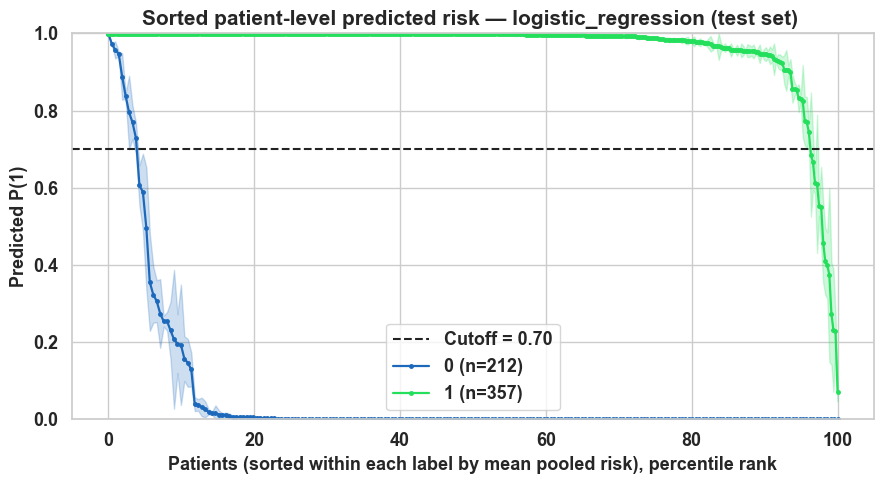

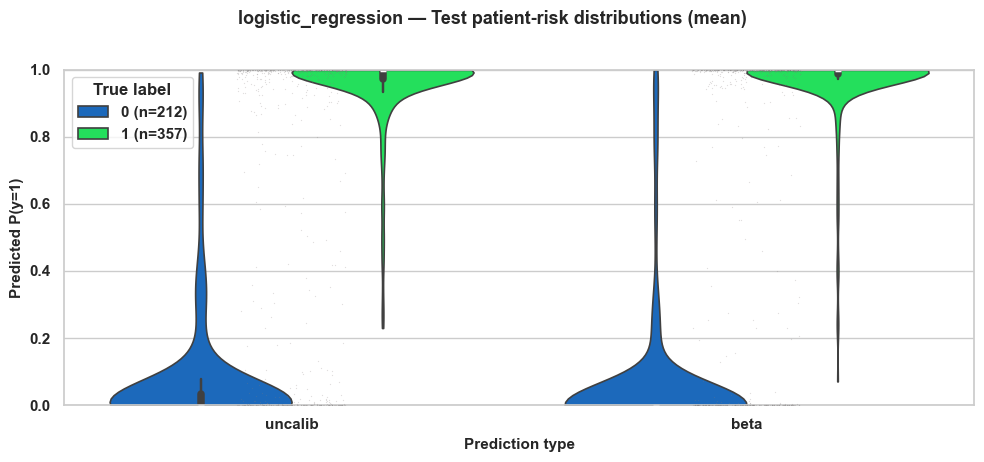

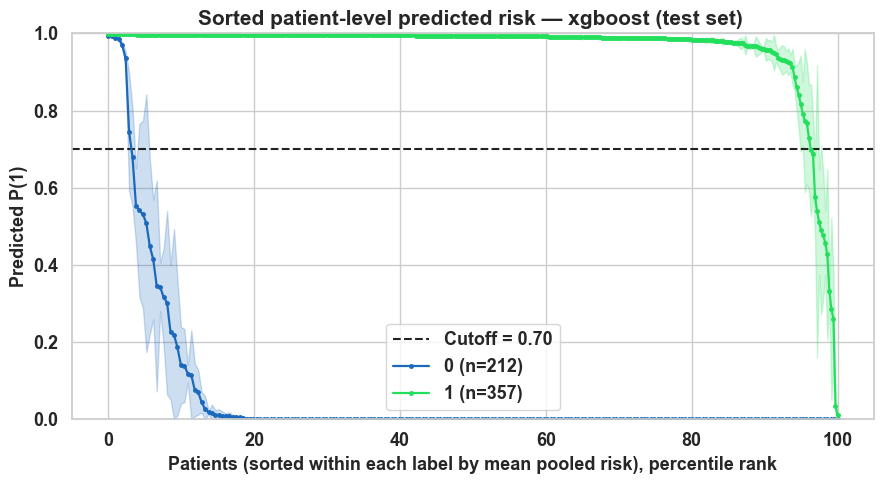

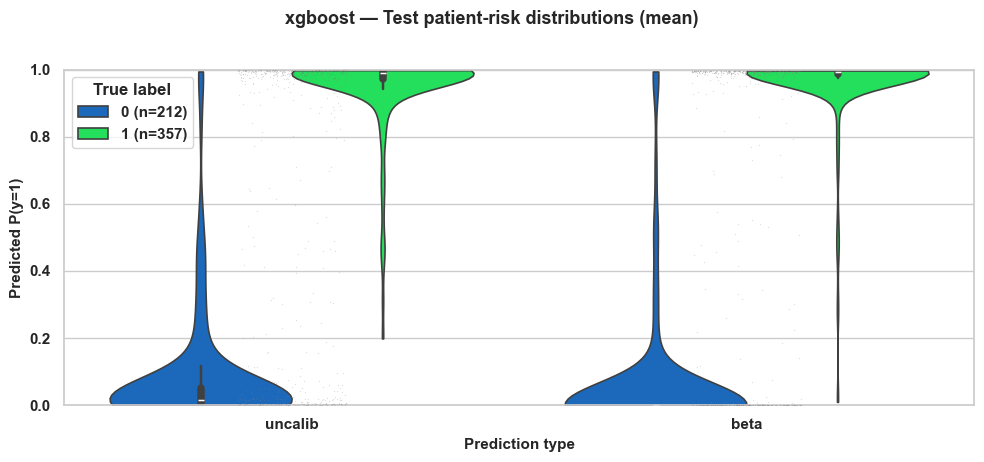

In [15]:

neg_plot_color = "#1C69BB"
pos_plot_color = "#24DF5C"


# Fixed prognostic enrichment threshold:
# patients with predicted probability of treatment response >= 0.70
# are treated as selected into the response-enriched subgroup.
threshold = 0.70

df_long = mtci.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    groups_all = None,
    group_id_to_key=None,
    include_uncalibrated=True,
    include_test=True,
    include_train_oof=False,   # keep off for now
    unit_col="idx"
)


df_pat = mtci.pooled_patient_risk_summary(
    df_long,
    grouping="all_trials", # per_trial_fold
    unit_col="idx",
    agg="mean",
    lower_q=0.0,
    upper_q=1.0,
    include_test=True,
    include_train_oof=False,
    truncate_decimals=3,
)



out_pat = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="logistic_regression",
    variants=[ "beta"],
    colors=[neg_plot_color, pos_plot_color],   
    split="test",
    group_label=None,            
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)




_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="logistic_regression",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)": neg_plot_color, "1 (pos)": pos_plot_color},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "0", "1 (pos)": "1"},
)






out_pat_xgb = mtci.plot_ranked_patients_patient_level(
    df_pat,
    model="xgboost",
    variants=[ "beta"],
    colors=[neg_plot_color, pos_plot_color],   
    split="test",
    group_label=None,               
    center_col="p_mean",
    std_col="p_total_std",
    prob_label=1,
    show_prevalence_baseline=False,
    make_overlay=True,
    make_separate=False,
    font_size=13,
    figsize_overlay=(9, 5),
    figsize_single=(9, 4),
    show_cutoff_lines=True,
    cutoffs = threshold, 
    cutoff_color = "#222222",
    cutoff_lw = 1.5,
    cutoff_ls = "--",
    cutoff_labels = True,                       # whether to add legend labels
    cutoff_label_fmt = "Cutoff = {c:.2f}",
    x_mode='percentile', # or 'index', 'percentile'
)


_ = mtci.plot_patient_risk_distributions_by_outcome(
    df_pat,
    model_name="xgboost",
    split="test",
    variants=["uncalib", "beta"],
    value_col="p_mean",
    unit_col="idx",  # or "idx" in the single-row-per-patient world
    outcome_palette={"0 (neg)": neg_plot_color, "1 (pos)": pos_plot_color},
    jitter_palette={"0 (neg)": "#817D7D", "1 (pos)": "#817D7D"},
    prevalence=False,
    outcome_legend_alias={"0 (neg)": "0", "1 (pos)": "1"},
)



## Patient Stratification by Predicted Response Probability

This section defines patient strata using intervals of the pooled patient-level predicted probability.

Instead of applying one threshold to select a single response-enriched subgroup, stratification divides the screened population into ordered probability groups. In this example, patients are assigned to one of three strata:

- **Low**: predicted probability from 0.00 to 0.30
- **Medium**: predicted probability from 0.30 to 0.70
- **High**: predicted probability from 0.70 to 1.00

The goal is to evaluate whether patients in higher predicted-probability strata have higher observed response rates and stronger response enrichment relative to the full screened population.

In [32]:
# Define score-based patient strata.
# The intervals are interpreted as:
#   lower_score_bound <= p_mean < upper_score_bound
#
# Here, patients are grouped into Low, Medium, and High predicted-response
# probability strata.
strata = [
    ("Low", 0.00, 0.30),
    ("Medium", 0.30, 0.70),
    ("High", 0.70, 1.00),
]


# Run the prognostic stratification summary for each model.
#
# This wrapper uses the generic stratification engine but renames the outputs
# using treatment-response terminology.
#
# For each model and stratum, the output summarizes:
#   - how many patients fall into the stratum,
#   - what fraction of the full population the stratum represents,
#   - how many responders and non-responders are in the stratum,
#   - the observed response and non-response rates,
#   - the response enrichment factor relative to the full screened population.
prognostic_strata = post.prognostic_stratification_summary_by_model(
    df=df_pat,                           # patient-level probability table
    strata=strata,                       # user-defined predicted-response probability intervals
    model=None,                          # run all available models in df_pat
    score_col="p_mean",                  # pooled patient-level predicted probability used for stratification
    variants="beta",                     # use beta-calibrated model outputs
    split="test",                        # summarize the test split
    meta_cols=["model", "variant", "split"],  # metadata columns retained in the output table
    subject_col="idx",            # patient identifier column
    y_col="y",                           # binary outcome; y=1 is interpreted as responder
    label_col="group_label",             # human-readable response/non-response label column, if available
)

prognostic_strata

,model,variant,split,score_col,stratum_order,stratum,score_low,score_high,pos_label,neg_label,...,n_responders_total,n_nonresponders_total,baseline_response_rate,n_stratum,pct_total,n_responders_stratum,n_nonresponders_stratum,stratum_response_rate,stratum_nonresponse_rate,response_enrichment_factor
0,logistic_regression,beta,test,p_mean,1,Low,0.0,0.3,1,0,...,357,212,0.627417,201,0.353251,4,197,0.019900,0.980100,0.031718
1,logistic_regression,beta,test,p_mean,2,Medium,0.3,0.7,1,0,...,357,212,0.627417,16,0.028120,10,6,0.625000,0.375000,0.996148
2,logistic_regression,beta,test,p_mean,3,High,0.7,1.0,1,0,...,357,212,0.627417,352,0.618629,343,9,0.974432,0.025568,1.553086
3,xgboost,beta,test,p_mean,1,Low,0.0,0.3,1,0,...,357,212,0.627417,198,0.347979,4,194,0.020202,0.979798,0.032199
4,xgboost,beta,test,p_mean,2,Medium,0.3,0.7,1,0,...,357,212,0.627417,21,0.036907,10,11,0.476190,0.523810,0.758970
5,xgboost,beta,test,p_mean,3,High,0.7,1.0,1,0,...,357,212,0.627417,350,0.615114,343,7,0.980000,0.020000,1.561961


## Visualizing Prognostic Stratification Results

This section visualizes the prognostic stratification results using the patient-level probability strata defined above.

Three summaries are displayed:

1. **Stratum size / feasibility**  
   Shows how many patients fall into each stratum. This helps assess whether each stratum is large enough to be useful for screening, recruitment, or subgroup planning.

2. **Response rate by stratum**  
   Shows the observed response rate within each stratum. This helps evaluate whether higher predicted-probability strata correspond to higher observed response rates.

3. **Response enrichment factor by stratum**  
   Shows how each stratum compares with the full screened population. A value above 1 indicates enrichment for responders relative to the baseline response rate, while a value below 1 indicates depletion.


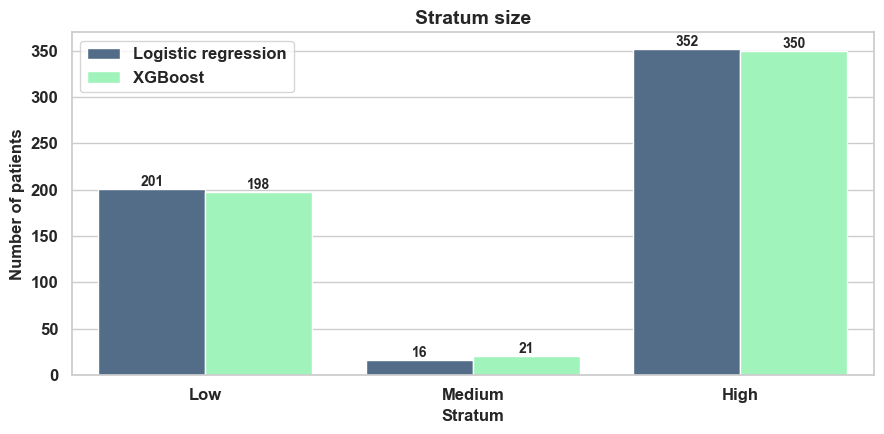

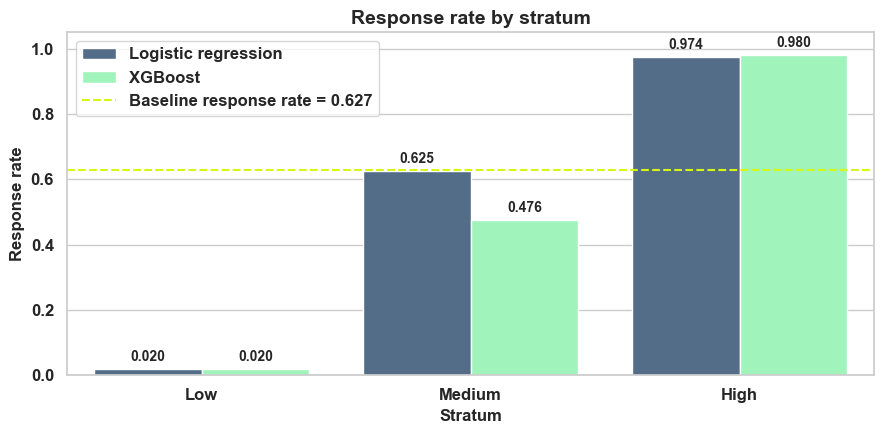

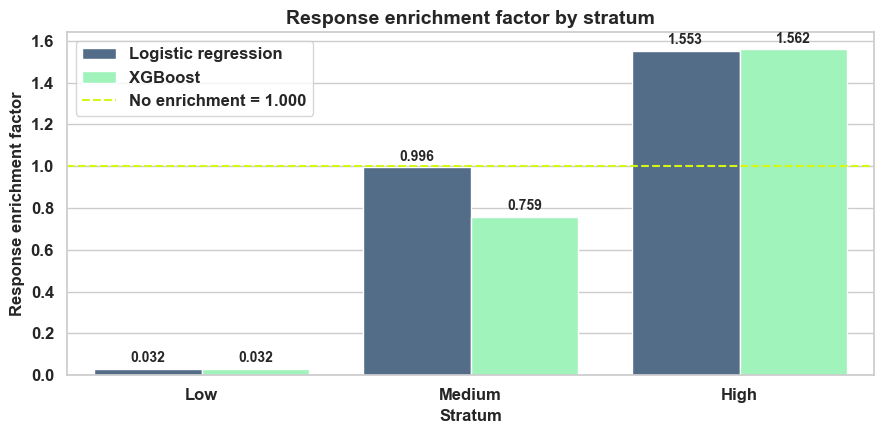

In [33]:
# Plot prognostic stratification summaries.
#
# This function creates a set of grouped bar plots from the prognostic
# stratification table. Here, we request three plot types:
#   1. size        -> how many patients are in each stratum
#   2. rate        -> observed response rate in each stratum
#   3. enrichment  -> response enrichment factor relative to baseline
#
# The input table `prognostic_strata` is the output of
# `prognostic_stratification_summary_by_model(...)`.

post.plot_stratification_summary_panels(
    strat_df=prognostic_strata,          # prognostic stratification summary table
    mode="prognostic",                   # interpret columns using treatment-response terminology
    variant="beta",                      # plot the beta-calibrated results
    split="test",                        # restrict the plots to the test split
    plots=("size", "rate", "enrichment"),# requested plot panels
    size_y="n_stratum",                  # size plot uses the number of patients in each stratum
    figsize=(9, 4.5),                    # figure size for each plot
    annotate_font_size=10,               # font size for bar-value annotations
    baseline_color="#D5F713",            # color of the horizontal baseline reference line
    font_size=12,                        # base font size for titles, axes, and legend
    model_alias={                        # cleaner display names for models in the legend
        "logistic_regression": "Logistic regression",
        "xgboost": "XGBoost",
    },
    model_palette={                      # colors used for each plotted model
        "Logistic regression": "#536D88",
        "XGBoost": "#9FF3BB",
    },
    rate_ylim=(0, 1.05),                 # y-axis range for the response-rate plot
)

### Chapter 2. Prospective enrichment workflow

This chapter demonstrates how the fixed enrichment rule is applied prospectively to patient-level data.

Given a set of screened patients, the ensemble model generates a patient-level predicted probability for each patient. The enrichment threshold is then applied to determine which patients are selected for the enriched cohort and which patients are not selected.

In [37]:

# Features used for model development: Select top k features
top_k = 7
lr_top = final_features['final_by_model']['logistic_regression']['feature_names_selected'][:top_k]
xgb_top  = final_features['final_by_model']['xgboost']['feature_names_selected'][:top_k]


feature_filters = {
    "logistic_regression": lr_top,
    "xgboost": xgb_top
}

model_data_dict = post.synthetic_data_validation(
    final_features=final_features,
    feature_filters=feature_filters,
    make_semisynthetic=True,
    semisynthetic_n_per_class=50,
    semisynthetic_noise_scale=0.50,  # 50% of each feature's SD
    semisynthetic_clip_to_observed_range=True,
    semisynthetic_random_state=42,
)


### **Ensemble scoring** and enrichment decision
For each example patient, repeated model predictions are aggregated to obtain a patient-level ensemble probability.

Patients with predicted probability above the fixed threshold are selected for enrichment, while patients below the threshold are not selected.

In [38]:
# Synthetic data prep.
cols_lg = lr_top + ['y']
cols_xgb =   xgb_top + ['y']

test_data = {}
test_data['logistic_regression'] = model_data_dict['logistic_regression']['df_semisynthetic'][cols_lg]
test_data['xgboost']             = model_data_dict['xgboost']['df_semisynthetic'][cols_xgb]


# Generate external-set predictions for every fold model in `all_results` and store them back into each fold record using `*_external_*` keys (metrics only if labels exist).
#all_results    = mtci.load_all_results(output_dir='abcct_dataset_outputs/run_1/nonlinear_features', prefix='final_result', compress=True)
#all_results       = mtci.load_all_results(output_dir='tutorial/run_1/breast_cancer', prefix='final_result', compress=True)

all_results = vld.add_external_predictions_to_results(
    all_results,
    model_data_dict=test_data,
    y_col=None,   # or None if unlabeled, or just add the label column if present
    external_tag="external",
    feature_names_key="feature_names_used",
    strict_features=True,
)


# Build a single long-form  predictions table with one row per predicted example that is pooled across models. 
df_long = vld.build_long_predictions_df(
    all_results,
    model_name=None,
    methods=["beta"],
    include_uncalibrated=False,
)

# Aggregate repeated predictions per idx into a single row per (model, variant, idx), and optionally add an "ensemble" model by pooling predictions across multiple models.
df_agg = vld.aggregate_predictions_by_idx(
    df_long,
    calibrations=["uncalib", "beta"],
    add_ensemble=True,
    ensemble_name="Ensemble model",
    ensemble_models=None, #["logistic_regression", "xgboost"],  # optional; otherwise pools all selected
    truncate_decimals=3,
)

df_agg.head()

,model,calibration,idx,y,n_preds,p_mean,p_median,p_std,p_min,p_max,split,y_label,prevalence_used
0,Ensemble model,beta,0,NaN,30,0.975,0.981,0.025,0.856,0.998,external,NaN,NaN
1,Ensemble model,beta,1,NaN,30,0.996,0.996,0.005,0.970,0.999,external,NaN,NaN
2,Ensemble model,beta,2,NaN,30,0.989,0.990,0.011,0.934,0.999,external,NaN,NaN
3,Ensemble model,beta,3,NaN,30,0.870,0.900,0.104,0.596,0.976,external,NaN,NaN
4,Ensemble model,beta,4,NaN,30,0.069,0.014,0.151,0.000,0.718,external,NaN,NaN


### Plot prospective patient stratification using aggregated patient-level predictions


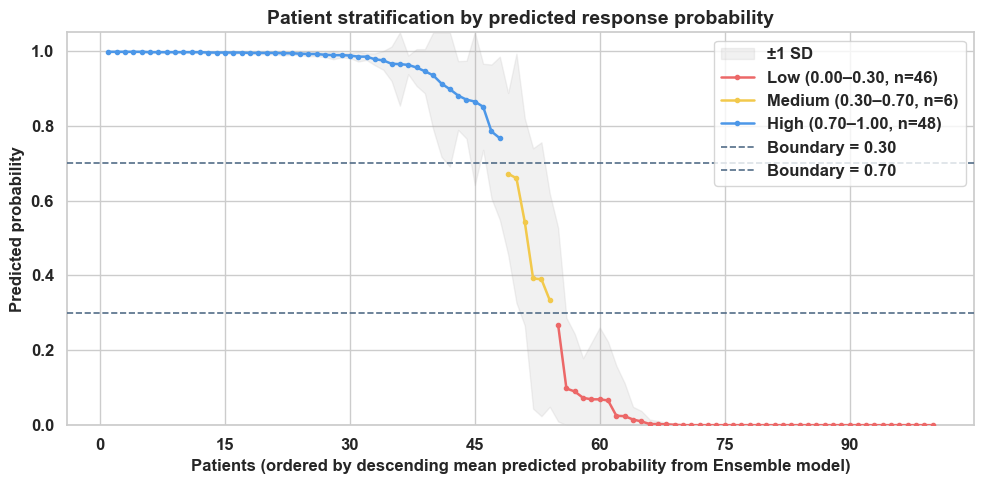

In [39]:
# Plot prospective patient stratification using aggregated patient-level predictions.
#
# In this stratification mode, no single enrichment cutoff is used.
# Instead, patients are assigned to probability-based strata:
#   Low    : 0.00 <= p_mean < 0.30
#   Medium : 0.30 <= p_mean < 0.70
#   High   : 0.70 <= p_mean <= 1.00
#
# The plot ranks patients by predicted probability and colors them by stratum.
# The shaded ribbon shows prediction variability using ±1 SD.
ranked_dict = vld.plot_screening_predictions(
    df_pred=df_agg,                      # aggregated patient-level prediction table
    models=["Ensemble model"],           # plot only the ensemble model
    reference_order_model="Ensemble model",  # model used to define patient ordering on the x-axis
    calibration="beta",                  # use beta-calibrated probabilities
    center_col="p_mean",                 # patient-level probability used for ranking and stratum assignment
    std_col="p_std",                     # patient-level uncertainty/spread used for the ±1 SD ribbon

    # Stratification mode
    cutoff=None,                         # no single enrichment cutoff; use strata instead
    strata=[                             # probability intervals used to assign patients to strata
        ("Low", 0.00, 0.30),
        ("Medium", 0.30, 0.70),
        ("High", 0.70, 1.00),
    ],

    # Plot appearance
    figsize=(10, 5),                     # figure size
    ylim=(0, 1.05),                      # y-axis range with slight padding above 1.0
    method_alias={                       # display names used in plot labels
        "Ensemble model": "Ensemble model",
    },
    strata_colors={                      # colors used for each probability stratum
        "Low": "#EC6868",
        "Medium": "#F2C94C",
        "High": "#4C97E8",
    },
    ribbon_color_single_model="#ADAAAA", # neutral ribbon color for prediction variability
    strata_boundary_color="#536D88",     # color for horizontal lines marking stratum boundaries
    title_prefix="Patient stratification by predicted response probability",
)